In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("../data/cumulative.csv") 
print(df.shape)          
print(df.head())
print(df.info())
print(df.describe())

(9564, 50)
   rowid     kepid kepoi_name   kepler_name koi_disposition koi_pdisposition  \
0      1  10797460  K00752.01  Kepler-227 b       CONFIRMED        CANDIDATE   
1      2  10797460  K00752.02  Kepler-227 c       CONFIRMED        CANDIDATE   
2      3  10811496  K00753.01           NaN  FALSE POSITIVE   FALSE POSITIVE   
3      4  10848459  K00754.01           NaN  FALSE POSITIVE   FALSE POSITIVE   
4      5  10854555  K00755.01  Kepler-664 b       CONFIRMED        CANDIDATE   

   koi_score  koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  ...  \
0      1.000              0              0              0  ...   
1      0.969              0              0              0  ...   
2      0.000              0              1              0  ...   
3      0.000              0              1              0  ...   
4      1.000              0              0              0  ...   

   koi_steff_err2  koi_slogg  koi_slogg_err1  koi_slogg_err2  koi_srad  \
0           -81.0      4.467         

In [3]:
print(df['koi_disposition'].value_counts())

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64


In [ ]:
# 1. Define columns to drop (ID and non-predictive metadata)
cols_to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 
    'koi_pdisposition', 'koi_score',                
    'koi_tce_delivname', 'koi_tce_plnt_num'         
]
# 2. Collect all error/uncertainty columns (containing 'err')
err_columns = [col for col in df.columns if 'err' in col]
# 3. Combine drop lists
final_drop_list = cols_to_drop + err_columns
# 4. Perform the drop to clean the dataframe
df_cleaned = df.drop(columns=final_drop_list)
# 5. Define the 15 physical feature columns 
physical_features = [
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 
    'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 
    'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 
    'ra', 'dec', 'koi_kepmag'
]

# 6. Final selection
df_final = df_cleaned[physical_features + ['koi_disposition']].copy()
# 8. Print Summary for confirmation
print(f"Final Shape: {df_final.shape} ")

# 9. THIS LINE TRIGGERS THE DATA VIEW ICON
df_final.head()

Final Shape: (9564, 16) 


,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_disposition
0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347,CONFIRMED
1,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347,CONFIRMED
2,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436,FALSE POSITIVE
3,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597,FALSE POSITIVE
4,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509,CONFIRMED


In [12]:
# Check missing values
print(df_final.isnull().sum())

koi_period           0
koi_time0bk          0
koi_impact         363
koi_duration         0
koi_depth          363
koi_prad           363
koi_teq            363
koi_insol          321
koi_model_snr      363
koi_steff          363
koi_slogg          363
koi_srad           363
ra                   0
dec                  0
koi_kepmag           1
koi_disposition      0
dtype: int64


In [15]:
for col in df_final.columns:
    if df_final[col].dtype != 'object': 
        if df_final[col].isnull().any():
            median_val = df_final[col].median()
            df_final[col] = df_final[col].fillna(median_val)
            print(f"{col}: filled with median = {median_val:.4f}")

# Final check 
print(f"Total missing values in df_final: {df_final.isnull().sum().sum()}")

Total missing values in df_final: 0


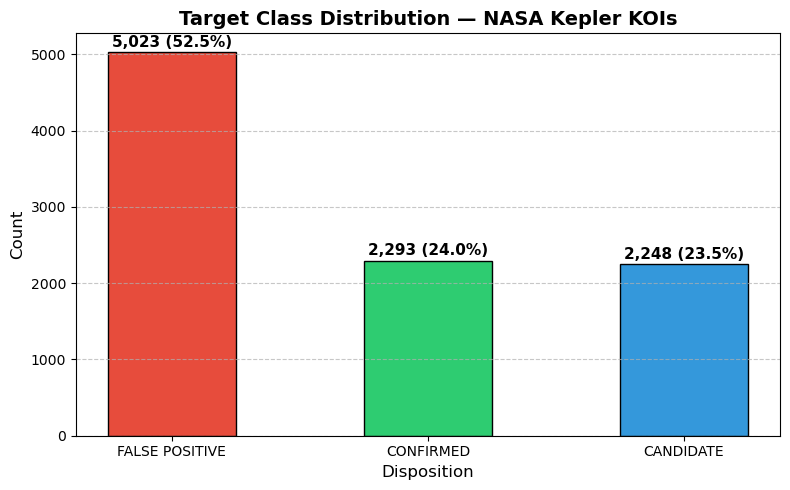

In [17]:
# Target Distribution 
counts = df_final['koi_disposition'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             f'{val:,} ({val/len(df_final)*100:.1f}%)', # Changed to df_final
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Target Class Distribution — NASA Kepler KOIs", fontsize=14, fontweight='bold')
plt.xlabel("Disposition", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added a subtle grid for better readability
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150)
plt.show()

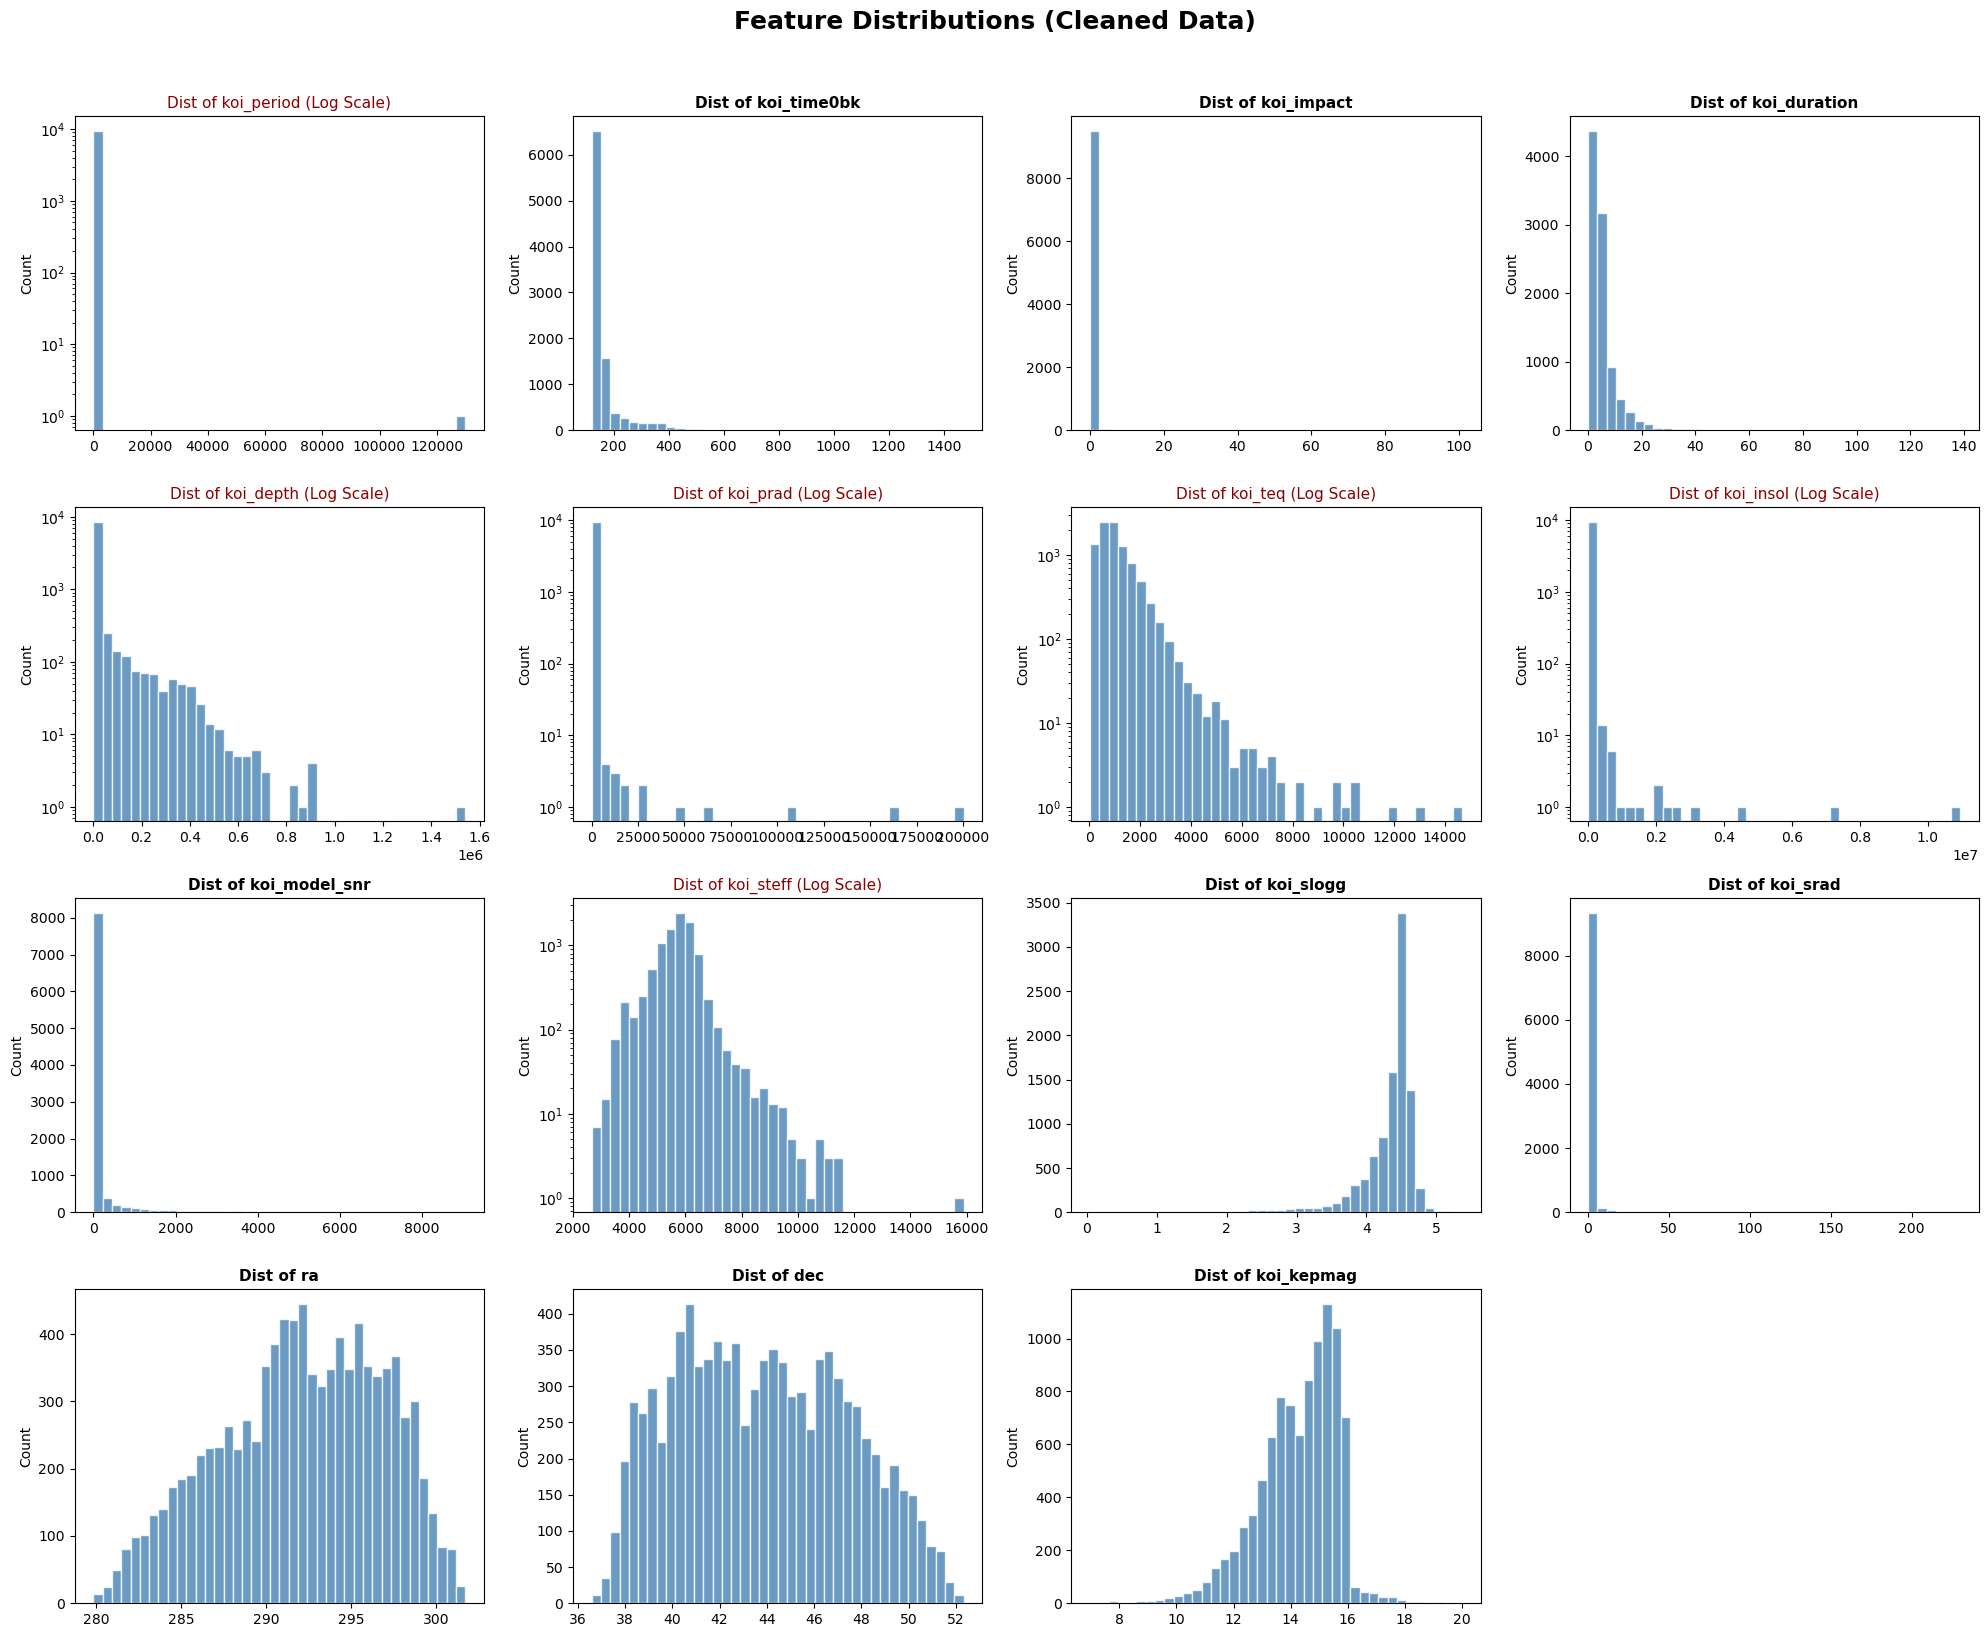

In [20]:
# EDA — Feature Distributions (Histograms) 

# 1. Define feature_cols 
feature_cols = [
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 
    'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 
    'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 
    'ra', 'dec', 'koi_kepmag'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

# Iterate through your 15 features
for i, col in enumerate(feature_cols):
    axes[i].hist(df_final[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f"Dist of {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Count")
    
    if df_final[col].max() > 10000: 
        axes[i].set_yscale('log')
        axes[i].set_title(f"Dist of {col} (Log Scale)", fontsize=11, color='darkred')

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions (Cleaned Data)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("02_feature_distributions.png", dpi=150)
plt.show()

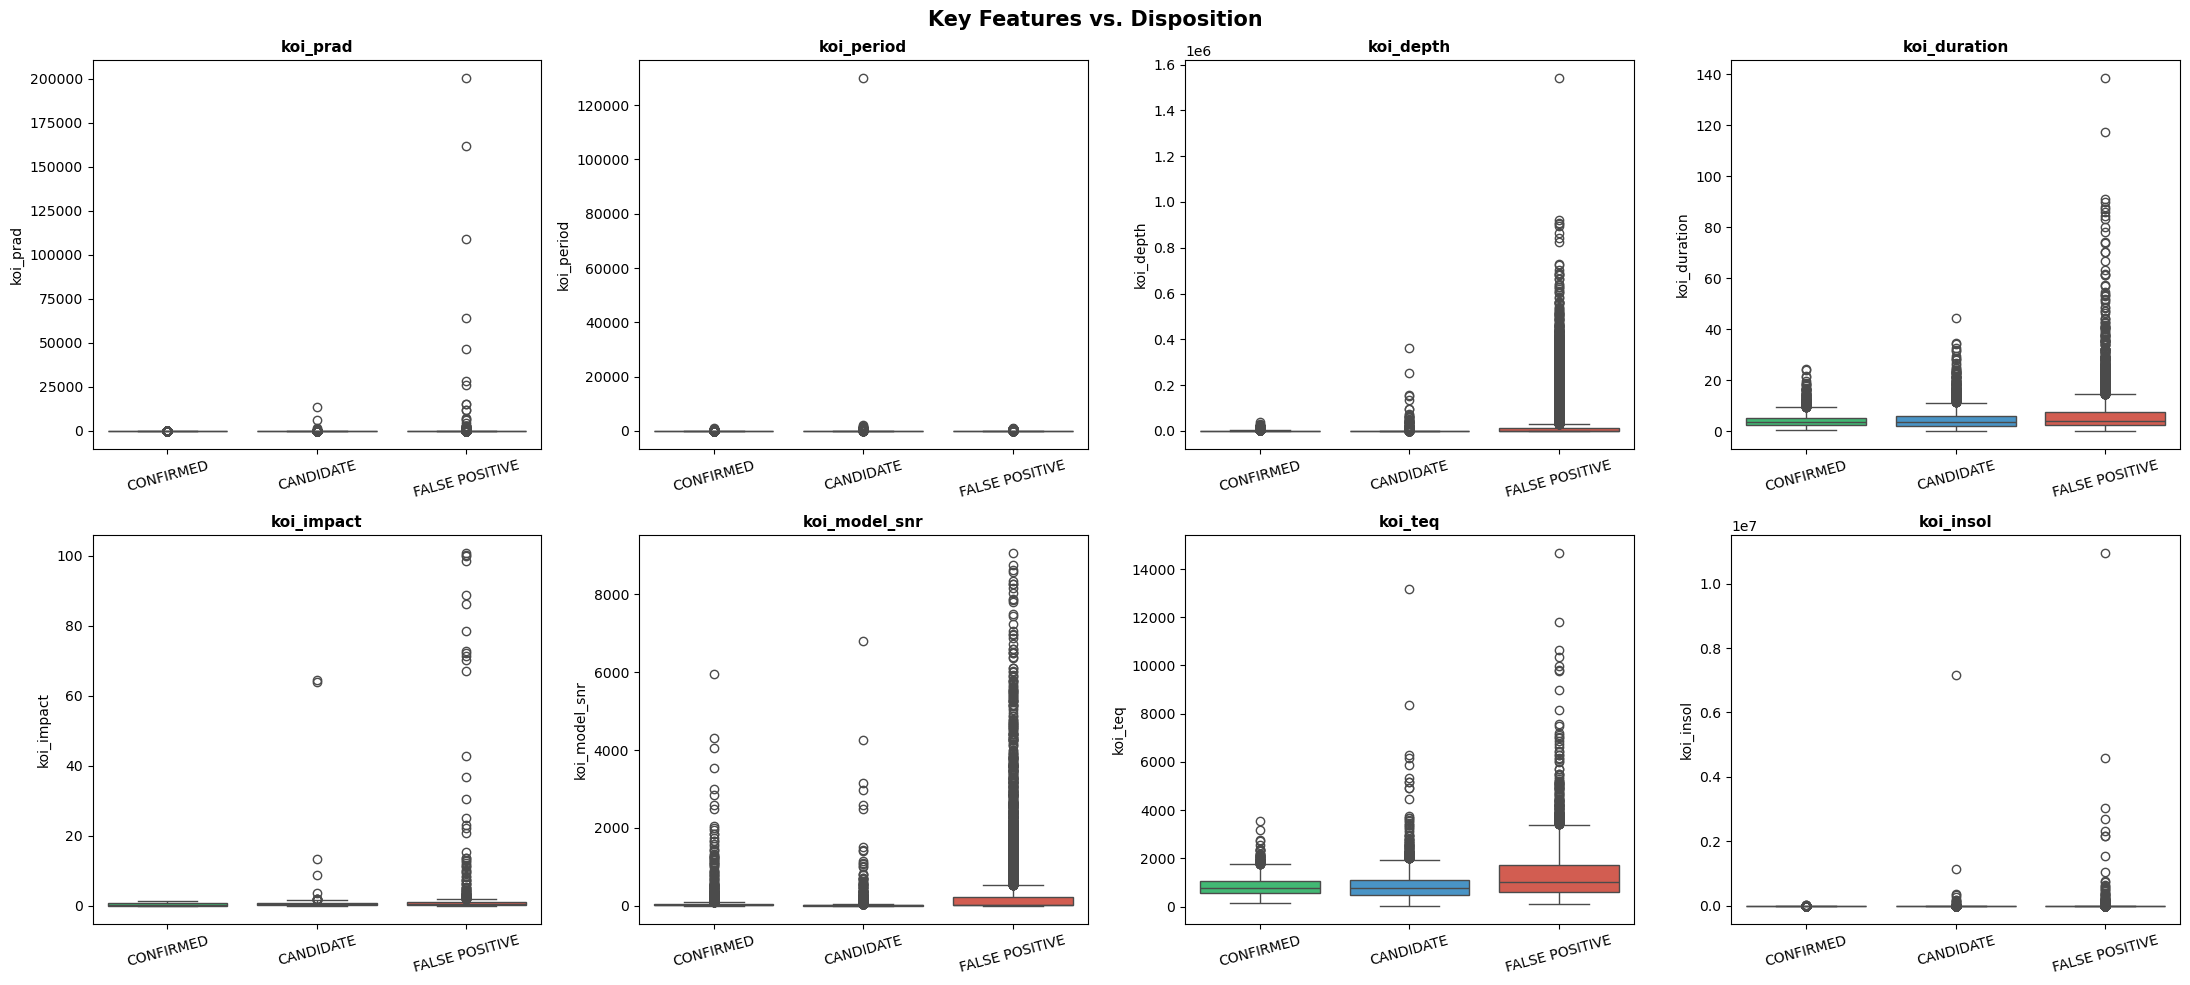

In [ ]:
#  Boxplots per Class 
key_features = ['koi_prad', 'koi_period', 'koi_depth', 'koi_duration', 
                'koi_impact', 'koi_model_snr', 'koi_teq', 'koi_insol']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

palette = {'CONFIRMED': '#2ecc71', 'FALSE POSITIVE': '#e74c3c', 'CANDIDATE': '#3498db'}

for i, col in enumerate(key_features):
    sns.boxplot(x='koi_disposition', y=col, data=df_final, 
                hue='koi_disposition', palette=palette, ax=axes[i],
                order=['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'],
                legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle("Key Features vs. Disposition", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

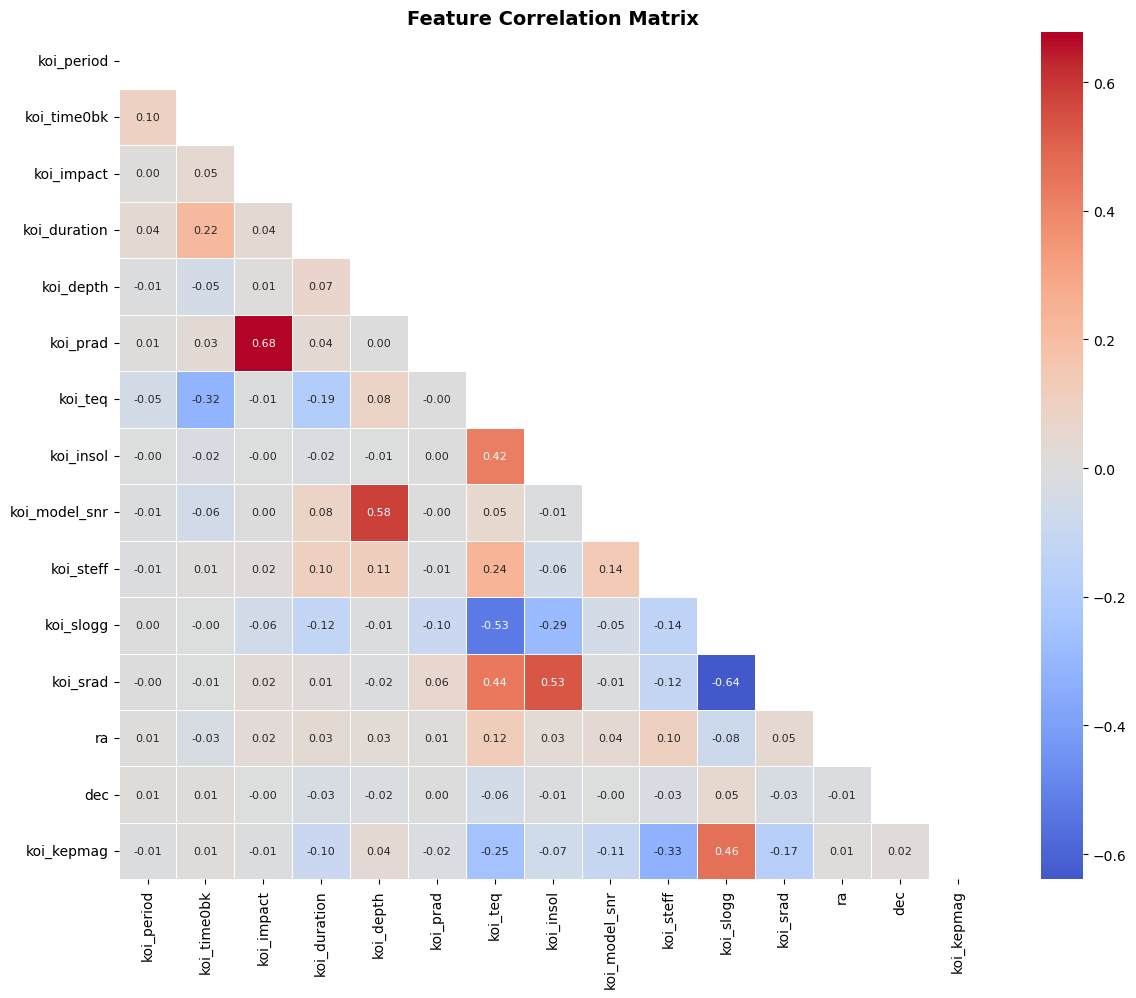

In [24]:
# Correlation Heatmap 
corr = df_final[feature_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool)) 

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            annot_kws={"size": 8}, linewidths=0.5)

plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

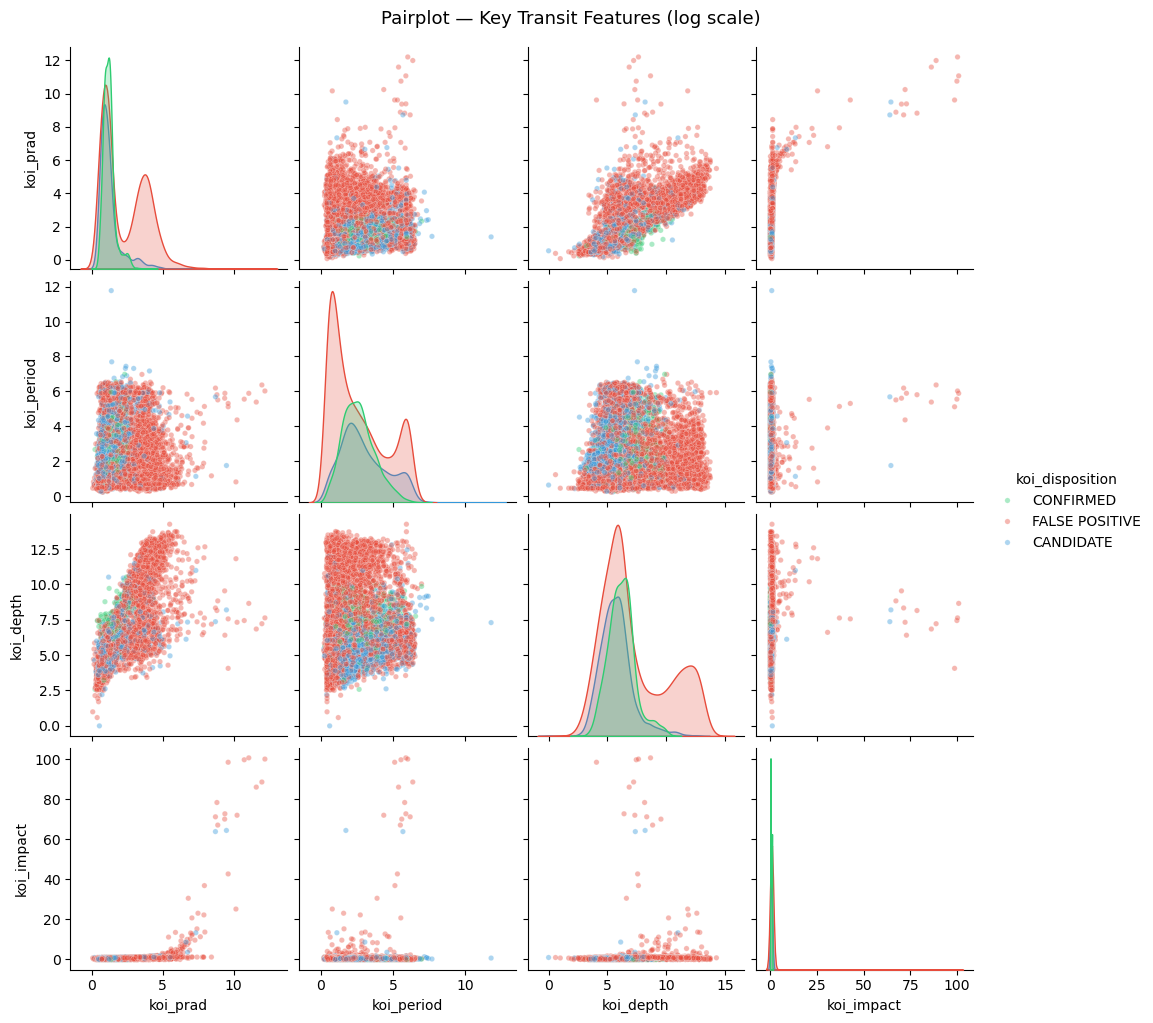

In [ ]:
#  Pairplot (Top 4 Features) 
pair_features = ['koi_prad', 'koi_period', 'koi_depth', 'koi_impact', 'koi_disposition']
df_pair = df_final[pair_features].copy()

for col in ['koi_prad', 'koi_period', 'koi_depth']:
    df_pair[col] = np.log1p(df_pair[col])

g = sns.pairplot(df_pair, hue='koi_disposition', palette=palette, 
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.figure.suptitle("Pairplot — Key Transit Features (log scale)", y=1.02, fontsize=13)
plt.show()

In [26]:
#  Encode Target Column 
le = LabelEncoder()
df_final['target'] = le.fit_transform(df_final['koi_disposition'])
print(f"Target Encoding Map: {dict(zip(le.classes_, le.transform(le.classes_)))}")

#  Scale Features 
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(df_final[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled_values, columns=feature_cols)

Target Encoding Map: {'CANDIDATE': np.int64(0), 'CONFIRMED': np.int64(1), 'FALSE POSITIVE': np.int64(2)}


In [27]:
#  Final Assembly and Save 
df_final_scaled = X_scaled_df.copy()
df_final_scaled['koi_disposition'] = df_final['koi_disposition'].values
df_final_scaled['target'] = df_final['target'].values

df_final_scaled.to_csv("cumulative_clean_scaled.csv", index=False)

print(f" Done: {df_final_scaled.shape}")

 Done: (9564, 17)
